In [1]:
import os
import csv
import datetime as dt
import pandas as pd

# index를 날짜로 하는 데이터프레임을 price, adj_price, divend에 대해 반환
def extract_stock_data(file_path, ticker):
    extract_datas = []

    with open(os.path.join(file_path, ticker + '.csv'), newline='') as csvfile:
        reader = csv.reader(csvfile)

        for row in reader:
            extract_datas.append(row)
        
    price_dates = list(map(dt.date.fromisoformat, extract_datas[0]))
    price_history = list(map(float, extract_datas[1]))
    adj_price_dates = list(map(dt.date.fromisoformat, extract_datas[2]))
    adj_price_history = list(map(float, extract_datas[3]))
    divend_dates = list(map(dt.date.fromisoformat, extract_datas[4]))
    divend_history = list(map(float, extract_datas[5]))

    price_df = pd.DataFrame({'date': price_dates, 'price': price_history})
    adj_price_df = pd.DataFrame({'date': adj_price_dates, 'adj_price': adj_price_history})
    divend_df = pd.DataFrame({'date': divend_dates, 'divend': divend_history})

    price_df.set_index('date', inplace=True)
    adj_price_df.set_index('date', inplace=True)
    divend_df.set_index('date', inplace=True)

    return (price_df, adj_price_df, divend_df)

def make_stock_data(file_path, tickers):
    stock_data = []

    for ticker in tickers:
        price_df, adj_price_df, divend_df = extract_stock_data(file_path, ticker)
        stock_df = pd.concat([price_df, adj_price_df, divend_df], axis=1, sort=True)
        stock_df.columns = pd.MultiIndex.from_product([[ticker], stock_df.columns])
        stock_data.append(stock_df)

    stock_data = pd.concat(stock_data, axis=1, sort=True)

    return stock_data


In [2]:
from portfolio import Portfolio

# stock 불러와서 데이터프레임화 하기
file_path = './etf'
tickers = ['QQQ', 'DGRW', 'SCHD', 'SPY', 'SCHG', 'SPYG']
stock_data = make_stock_data(file_path, tickers)
pd.options.display.float_format = '{:.2f}'.format

test_stock = Portfolio(stock_data, 10000)

In [5]:
corr = test_stock.stock_corr()
corr

,SPY,QQQ,SPYG,DGRW,SCHD,SCHG
SPY,1.00,0.93,0.97,0.97,0.88,0.96
QQQ,0.93,1.00,0.97,0.87,0.72,0.98
SPYG,0.97,0.97,1.00,0.90,0.76,0.99
DGRW,0.97,0.87,0.90,1.00,0.93,0.89
SCHD,0.88,0.72,0.76,0.93,1.00,0.74
SCHG,0.96,0.98,0.99,0.89,0.74,1.00


In [3]:
def calc_target_ratio(base_ratio:tuple, etc_ratio:tuple) -> tuple:
    base_sum = sum(base_ratio)
    qqq = base_ratio[0] / base_sum * 100
    etc_sum = sum(etc_ratio)
    etc1 = (etc_ratio[0] / etc_sum) * (base_ratio[1] / base_sum) * 100
    etc2 = (etc_ratio[1] / etc_sum) * (base_ratio[1] / base_sum) * 100

    return (round(qqq, 1), round(etc1, 1), round(etc2, 1))

In [4]:
from joblib import Parallel, delayed
from portfolio_test import portfolio_backtest_by_duration
benchmark = stock_data[('QQQ', 'adj_price')]

In [ ]:
# target_ratio를 변경해서 벡테스트
ratio_change_stats = pd.DataFrame(columns=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])

param_list = []
for qqq_weight in range(0, 100, 5):
    for schd_weight in range(0, 10):
        ratio_qqq_etc = (qqq_weight, 100 - qqq_weight)
        ratio_schd_dgrw = (schd_weight, 10 - schd_weight)
        ratio_qqq_schd_dgrw = calc_target_ratio(ratio_qqq_etc, ratio_schd_dgrw)
        
        target_ratio = {
            'QQQ': ratio_qqq_schd_dgrw[0],
            'SCHD': ratio_qqq_schd_dgrw[1],
            'DGRW': ratio_qqq_schd_dgrw[2]
        }
        print(target_ratio)    
        p = Portfolio(stock_data, 10000, target_ratio)
        param_list.append((p, benchmark, 5))

with Parallel(n_jobs=-1) as parallel:
        results = parallel(delayed(portfolio_backtest_by_duration)(*params) for params in param_list)
        
for stat in results:
    ratio_change_stats = pd.concat([ratio_change_stats, stat])

In [8]:
# buy, sell ratio를 변경해서 백테스트
buysell_ratio_stats = pd.DataFrame(columns=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])

target_ratio_list = [
    { 'QQQ': 30, 'SCHD': 49, 'DGRW': 21 },
    { 'QQQ': 35, 'SCHD': 58.5, 'DGRW': 6.5 },
    { 'QQQ': 40, 'SCHD': 48, 'DGRW': 12 },
    { 'QQQ': 40, 'SCHD': 36, 'DGRW': 24 },
    { 'QQQ': 50, 'SCHD': 35, 'DGRW': 15 },
    { 'QQQ': 50, 'SCHD': 45, 'DGRW': 5 },
    { 'QQQ': 55, 'SCHD': 40, 'DGRW': 4.5 }
]
param_list = []
for target_ratio in target_ratio_list:
    for buy_ratio in range(1, 16):
        for sell_ratio in range(1, 16):
            print(f'target_ratio: {target_ratio}, buy_ratio: {buy_ratio}, sell_ratio: {sell_ratio}')
            p = Portfolio(stock_data, 10000, target_ratio, buy_ratio=buy_ratio, sell_ratio=sell_ratio)
            param_list.append((p, benchmark, 5))
            
with Parallel(n_jobs=-1) as parallel:
        results = parallel(delayed(portfolio_backtest_by_duration)(*params) for params in param_list)

for i, stat in enumerate(results):
    p = param_list[i][0]
    stat.insert(len(stat.columns), 'b_r', p.buy_ratio)
    stat.insert(len(stat.columns), 's_r', p.sell_ratio)
    buysell_ratio_stats = pd.concat([buysell_ratio_stats, stat])

target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 1
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 2
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 3
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 4
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 5
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 6
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 7
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 8
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 9
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 10
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 11
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 12
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}

In [17]:
buysell_ratio_stats.to_csv('./buysell_ratio_stats.csv')

,cagr,stdev,mdd,beta,alpha,ratio,b_r,s_r
0,13.88,12.26,12.83,0.76,-1.01,30.0:49.0:21.0,1.00,1.00
1,11.78,13.18,18.76,0.73,-0.46,30.0:49.0:21.0,1.00,1.00
2,10.78,18.52,31.04,0.82,-3.00,30.0:49.0:21.0,1.00,1.00
3,20.35,18.67,31.07,0.77,-0.16,30.0:49.0:21.0,1.00,1.00
4,14.80,19.56,31.13,0.73,1.71,30.0:49.0:21.0,1.00,1.00
...,...,...,...,...,...,...,...,...
4,15.56,20.76,30.71,0.82,1.16,55.0:40.0:04.5,15.00,15.00
5,13.74,21.90,29.06,0.82,0.24,55.0:40.0:04.5,15.00,15.00
6,17.77,21.54,29.50,0.82,0.11,55.0:40.0:04.5,15.00,15.00
7,16.06,17.98,25.46,0.73,2.17,55.0:40.0:04.5,15.00,15.00


In [19]:
buysell_ratio_stats = pd.read_csv('./buysell_ratio_stats.csv', index_col=0)

In [ ]:
ratio_change_stats.to_csv('./stats_qqq_schd_dgrw.csv')

In [5]:
ratio_change_stats = pd.read_csv('./stats_qqq_schd_dgrw.csv', index_col=0)

In [8]:
stats = ratio_change_stats.copy()

In [6]:
stats = buysell_ratio_stats.copy()

NameError: name 'buysell_ratio_stats' is not defined

In [9]:
weight_map = {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0,
              5: 1.1, 6: 1.1,
              7: 1.2, 8: 1.2}

stats['weight'] = stats.index.map(lambda x: weight_map[x % 9])

def weighted_alpha_mean(group):
    d = group['alpha']
    w = group['weight']
    return (d * w).sum() / w.sum()

# stat_summary_weighted_alpha = stats.groupby(['ratio', 'b_r', 's_r']).apply(weighted_alpha_mean)
# stat_summary_mdd_quantile = stats.groupby(['ratio', 'b_r', 's_r'])['mdd'].quantile(0.25)
stat_summary_weighted_alpha = stats.groupby(['ratio']).apply(weighted_alpha_mean)
stat_summary_mdd_quantile = stats.groupby(['ratio'])['mdd'].quantile(0.25)


In [10]:

# stat_summary = stats.groupby(['ratio', 'b_r', 's_r']).mean()
stat_summary = stats.groupby(['ratio']).mean()
stat_summary['alpha'] = stat_summary_weighted_alpha
stat_summary.insert(3, 'mdd_quantile', stat_summary_mdd_quantile)
stat_summary.insert(4, 'mdd_diff', stat_summary['mdd'] - stat_summary['mdd_quantile'])
# stat_summary.insert(5, 'test',stat_summary['mdd_diff'].rank(pct=True) * 0.75 + 0.25)

stat_summary.insert(5, 'mdd_score', (stat_summary['mdd_diff'].rank(pct=True) * 0.75 + 0.25) * ((1 -stat_summary['mdd'].rank(pct=True)) * 0.5 + 0.5))
# stat_summary.sort_values(by='mdd_score', ascending=True, inplace=True)
# stat_summary = stat_summary[(stat_summary['cagr'] > 14) & (stat_summary['alpha'] > 0.1)]
# stat_summary.sort_values(by='mdd_score', ascending=False, inplace=True)

stat_summary

,cagr,stdev,mdd,mdd_quantile,mdd_diff,mdd_score,beta,alpha,weight
ratio,,,,,,,,,
0.0:0.0:100.0,12.35,16.01,24.62,16.93,7.69,0.95,0.64,-0.08,1.07
0.0:10.0:90.0,12.32,16.00,24.76,16.94,7.82,0.95,0.63,-0.00,1.07
0.0:20.0:80.0,12.28,16.01,24.86,16.94,7.91,0.95,0.63,0.06,1.07
0.0:30.0:70.0,12.22,16.01,24.90,16.97,7.93,0.95,0.62,0.12,1.07
0.0:40.0:60.0,12.26,16.05,24.89,16.95,7.94,0.95,0.61,0.27,1.07
...,...,...,...,...,...,...,...,...,...
95.0:2.5:2.5,18.07,21.24,28.56,28.00,0.56,0.29,0.97,-0.05,1.07
95.0:3.0:2.0,18.07,21.23,28.55,28.01,0.54,0.29,0.97,-0.05,1.07
95.0:3.5:1.5,18.07,21.23,28.55,28.02,0.53,0.29,0.97,-0.04,1.07


In [14]:
stat_summary = stats.groupby(['ratio']).mean()
stat_summary['alpha'] = stat_summary_weighted_alpha
stat_summary.insert(3, 'mdd_quantile', stat_summary_mdd_quantile)
stat_summary.insert(4, 'mdd_diff', stat_summary['mdd'] - stat_summary['mdd_quantile'])

stat_summary.insert(5, 'mdd_score', (stat_summary['mdd_diff'].rank(pct=True) * 0.75 + 0.25) * ((1 -stat_summary['mdd'].rank(pct=True)) * 0.5 + 0.5))

stat_summary = stat_summary[(stat_summary['cagr'] > 14) & (stat_summary['mdd_score'] > 0.5)]
stat_summary.sort_values(by='mdd_score', ascending=False, inplace=True)

stat_summary

,cagr,stdev,mdd,mdd_quantile,mdd_diff,mdd_score,beta,alpha,weight
ratio,,,,,,,,,
25.0:7.5:67.5,14.05,17.03,25.15,21.01,4.14,0.71,0.73,-0.00,1.07
25.0:15.0:60.0,14.01,16.99,25.23,20.92,4.31,0.70,0.72,0.03,1.07
25.0:0.0:75.0,14.10,17.11,25.18,21.16,4.01,0.69,0.73,-0.06,1.07
30.0:49.0:21.0,14.12,17.05,25.35,21.40,3.96,0.65,0.71,0.26,1.07
30.0:21.0:49.0,14.27,17.18,25.32,21.65,3.67,0.64,0.74,0.05,1.07
30.0:28.0:42.0,14.25,17.15,25.33,21.52,3.81,0.64,0.73,0.10,1.07
30.0:56.0:14.0,14.02,17.03,25.42,21.45,3.96,0.64,0.71,0.27,1.07
30.0:35.0:35.0,14.23,17.12,25.38,21.56,3.82,0.64,0.73,0.17,1.07
30.0:42.0:28.0,14.17,17.09,25.42,21.59,3.84,0.63,0.72,0.20,1.07


In [41]:
pd.set_option('display.max_rows', None)

stat_summary_sorted = stat_summary.sort_values(by=['alpha'], ascending=False)
stat_summary_sorted = stat_summary_sorted[stat_summary_sorted['alpha'] > 0]
stat_sorted = stats.sort_values(by=['ratio', 'alpha'], ascending=[True, False])

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.catplot(data=stats, x='ratio', y='cagr', kind='box')
sns.catplot(data=stats, x='ratio', y='stdev', kind='box')
sns.catplot(data=stats, x='ratio', y='mdd', kind='box')

In [ ]:
sns.relplot(data=stats, x='stdev', y='cagr', hue='ratio')

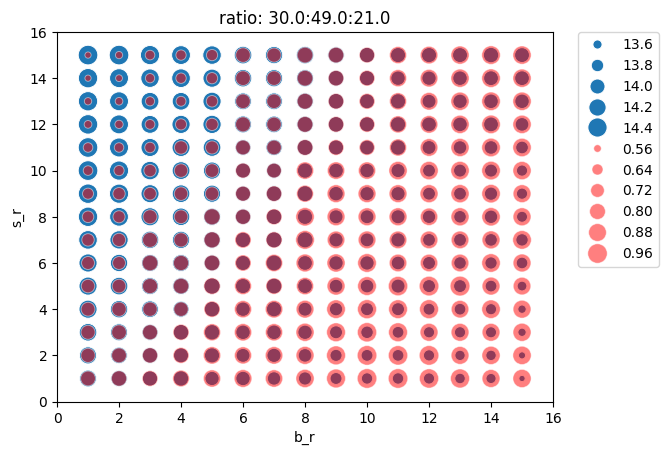

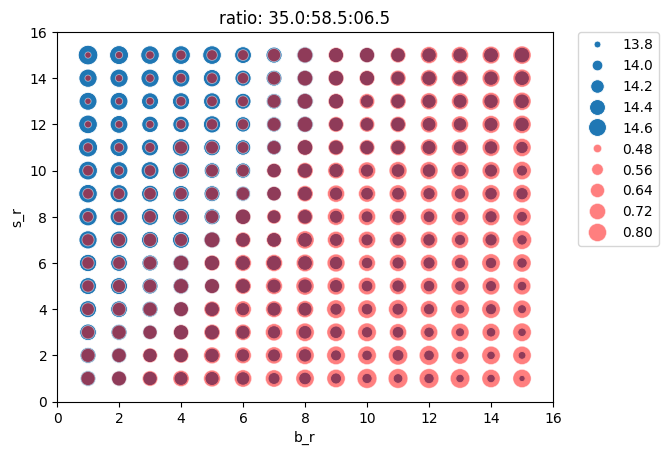

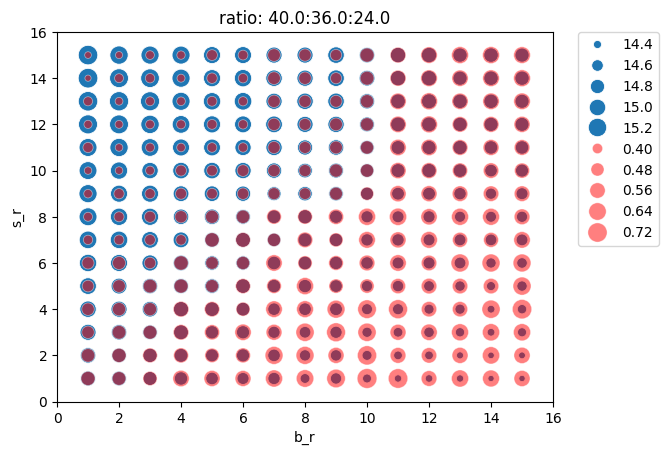

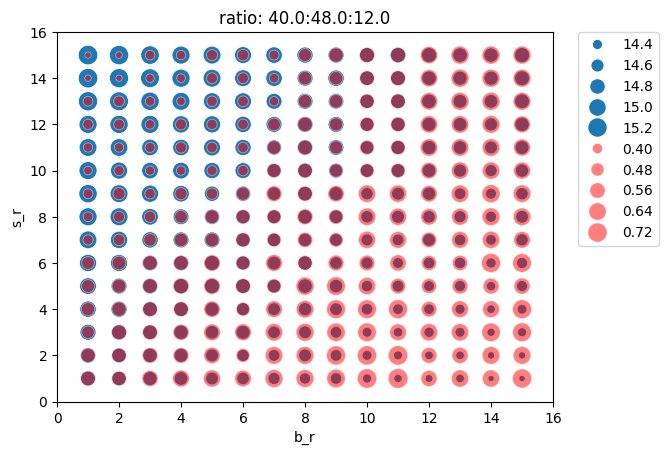

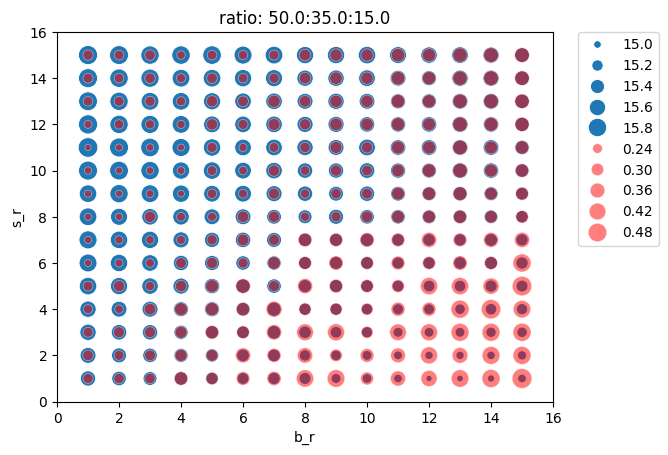

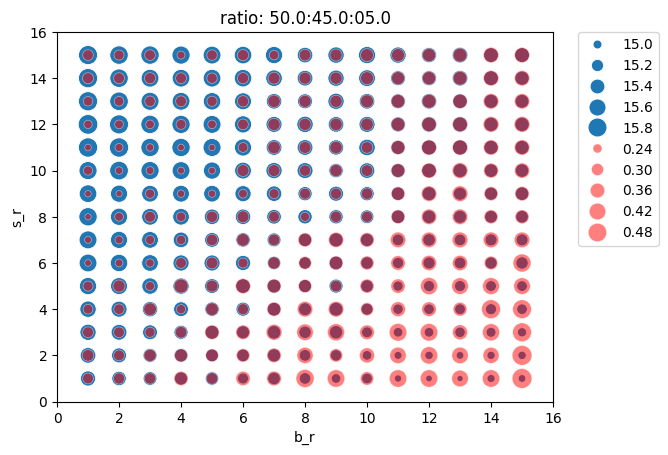

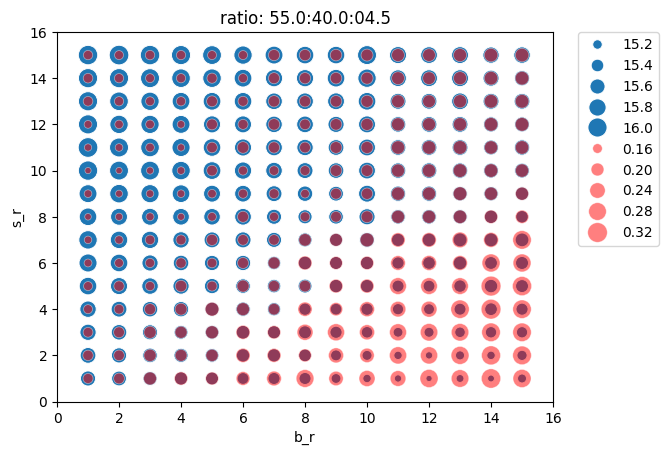

In [148]:
# plot = sns.catplot(data=stat_summary, x='alpha', y='ratio', kind='violin', color=".9")
# plot = sns.swarmplot(data=stat_summary, x='alpha', y='ratio', hue='ratio', dodge=True)
# filtered_stat_summary = stat_summary[(stat_summary['mdd_score'] > 0.6) & (stat_summary['cagr'] > 14.5)]
filtered_stat_summary = stat_summary

for ratio in filtered_stat_summary.index.get_level_values('ratio').unique():
    subset = filtered_stat_summary.xs(ratio, level='ratio')

    fig, ax = plt.subplots()
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 16)
    # plot = sns.relplot(data=subset, x='b_r', y='s_r', size='alpha', sizes=(20, 200))
    sns.scatterplot(data=subset, x='b_r', y='s_r', size='cagr', sizes=(20, 200), ax=ax)
    sns.scatterplot(data=subset, x='b_r', y='s_r', size='mdd_score', sizes=(20, 200), ax=ax, color='red', alpha=0.5)
    # plot.sns.relplot(data=subset, x='b_r', y='s_r', size='mdd_score', sizes=(20, 200))
    # plot.set(title=f'ratio: {ratio}')
    plt.title(f'ratio: {ratio}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.show()